In [1]:
from pathlib import Path
from typing import Literal

from datasets import concatenate_datasets

ROOT_DIR = Path.cwd().parent
DATASETS_DIR = ROOT_DIR / "datasets"

SplitName = Literal["train", "validation", "test"]
SPLITS: tuple[SplitName, ...] = ("train", "validation", "test")

print(DATASETS_DIR)


d:\projects\assessment\apple\siri-language-engineer\language-engineer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d:\projects\assessment\apple\siri-language-engineer\language-engineer\datasets


# Load parquet and prepare metrics

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset, load_dataset


def load_split_parquet(path: Path) -> Dataset:
    return load_dataset("parquet", data_files=str(path), split="train")


def word_count(text: str) -> int:
    return len(text.split())


def profile_dataset(ds: Dataset, sample_rows: int | None = 5000) -> dict:
    n = len(ds)
    if n == 0:
        raise ValueError("Dataset is empty.")

    sz = n if sample_rows is None else min(sample_rows, n)
    sample = ds if sz == n else ds.select(range(sz))

    docs = sample["document"]
    sums = sample["summary"]

    doc_chars = [len(t) for t in docs]
    sum_chars = [len(t) for t in sums]
    doc_words = [word_count(t) for t in docs]
    sum_words = [word_count(t) for t in sums]

    ratios: list[float] = []
    for dw, sw in zip(doc_words, sum_words, strict=True):
        ratios.append(sw / max(dw, 1))

    def summarize(arr: list[int] | list[float]) -> dict[str, float]:
        arr_np = np.array(arr, dtype=np.float64)
        return {
            "min": float(arr_np.min()),
            "p25": float(np.quantile(arr_np, 0.25)),
            "p50": float(np.quantile(arr_np, 0.50)),
            "p75": float(np.quantile(arr_np, 0.75)),
            "max": float(arr_np.max()),
        }

    empty_doc = sum(1 for t in docs if not t.strip()) / sz
    empty_sum = sum(1 for t in sums if not t.strip()) / sz

    return {
        "n_rows": n,
        "sample_size": sz,
        "empty_document_ratio_sample": empty_doc,
        "empty_summary_ratio_sample": empty_sum,
        "document_chars": summarize(doc_chars),
        "summary_chars": summarize(sum_chars),
        "document_words": summarize(doc_words),
        "summary_words": summarize(sum_words),
        "summary_to_doc_word_ratio": summarize(ratios),
        "sample_rows": sz,
        "docs": docs,
        "sums": sums,
        "doc_words": doc_words,
        "sum_words": sum_words,
        "ratios": ratios,
    }


def profile_split(parquet_path: Path, sample_rows: int | None = 5000) -> dict:
    ds = load_split_parquet(parquet_path)
    return profile_dataset(ds, sample_rows=sample_rows)


In [3]:
def plot_profiles(profile: dict, title_prefix: str = ""):
	_, axes = plt.subplots(1, 3, figsize=(16, 4))
	axes[0].hist(profile["doc_words"], bins=50, alpha=0.8)
	axes[0].set_title(f"{title_prefix} doc words")
	axes[1].hist(profile["sum_words"], bins=50, alpha=0.8)
	axes[1].set_title(f"{title_prefix} summary words")
	axes[2].hist(profile["ratios"], bins=50, alpha=0.8)
	axes[2].set_title(f"{title_prefix} sum/doc word ratio")
	plt.tight_layout()
	plt.show()

def plot_scatter(profile: dict, title_prefix: str = ""):
	plt.figure(figsize=(6, 5))
	plt.scatter(profile["doc_words"][:2000], profile["sum_words"][:2000], s=6, alpha=0.4)
	plt.title(f"{title_prefix} doc_words vs summary_words (sample)")
	plt.xlabel("document words")
	plt.ylabel("summary words")
	plt.show()

In [4]:
def iqr_bounds(arr: list[float], k: float = 1.5) -> tuple[float, float]:
    # Return (lower, upper) IQR fences for an array.
    arr_np = np.array(arr, dtype=np.float64)
    q1, q3 = np.quantile(arr_np, [0.25, 0.75])
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr)


def iqr_outliers(arr: list[float], k: float = 1.5) -> np.ndarray:
    # Boolean mask: True where value lies outside IQR fences.
    arr_np = np.array(arr, dtype=np.float64)
    lo, hi = iqr_bounds(arr, k)
    return (arr_np < lo) | (arr_np > hi)


def absolute_violations(profile: dict) -> dict:
    # Count rows that fail hard absolute thresholds (word-level, fast).
    doc_words = np.array(profile["doc_words"])
    sum_words = np.array(profile["sum_words"])
    ratios    = np.array(profile["ratios"])
    n = len(doc_words)
    checks = {
        "doc_words < 30   (too short to be 'long document')":  int((doc_words < 30).sum()),
        "doc_words > 1500 (training memory concern)":          int((doc_words > 1500).sum()),
        "sum_words < 10   (summary too short)":                int((sum_words < 10).sum()),
        "sum_words > 150  (summary not concise)":              int((sum_words > 150).sum()),
        "ratio > 1.0      (summary longer than document)":     int((ratios > 1.0).sum()),
        "ratio < 0.02     (overly compressed)":                int((ratios < 0.02).sum()),
        "ratio > 0.6      (barely compressed)":                int((ratios > 0.6).sum()),
    }
    return {"n": n, "checks": checks}


def plot_outliers(profile: dict, title_prefix: str = "") -> None:
    doc_words_np = np.array(profile["doc_words"])
    sum_words_np = np.array(profile["sum_words"])

    outlier_mask = iqr_outliers(profile["ratios"])
    normal_mask  = ~outlier_mask

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(
        doc_words_np[normal_mask], sum_words_np[normal_mask],
        s=4, alpha=0.25, color="steelblue",
        label=f"normal ({normal_mask.sum():,})",
    )
    axes[0].scatter(
        doc_words_np[outlier_mask], sum_words_np[outlier_mask],
        s=8, alpha=0.65, color="crimson",
        label=f"IQR outlier on ratio ({outlier_mask.sum():,})",
    )
    axes[0].set_title(f"{title_prefix} IQR outliers (ratio) -- doc vs summary words")
    axes[0].set_xlabel("document words")
    axes[0].set_ylabel("summary words")
    axes[0].legend(fontsize=8)

    lo, hi = iqr_bounds(profile["ratios"])
    axes[1].hist(profile["ratios"], bins=60, alpha=0.7, color="steelblue")
    axes[1].axvline(lo, color="crimson",    linestyle="--", linewidth=1.3,
                    label=f"IQR lower = {lo:.3f}")
    axes[1].axvline(hi, color="darkorange", linestyle="--", linewidth=1.3,
                    label=f"IQR upper = {hi:.3f}")
    axes[1].set_title(f"{title_prefix} ratio distribution + IQR fences")
    axes[1].set_xlabel("summary / document word ratio")
    axes[1].set_ylabel("count")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_validation_report(profile: dict, split_name: str = "") -> None:
    label  = f"[{split_name}]" if split_name else ""
    result = absolute_violations(profile)
    n      = result["n"]
    sep    = "=" * 64
    print(f"\n{sep}")
    print(f"  Validation Report {label}   n = {n:,}")
    print(sep)
    for desc, count in result["checks"].items():
        pct  = count / n * 100
        flag = "  <<" if pct > 1.0 else ""
        print(f"  {desc:<54}  {count:>6,}  ({pct:5.2f}%){flag}")
    for field, lbl in [("ratios", "ratio"), ("doc_words", "doc_words")]:
        mask  = iqr_outliers(profile[field])
        count = int(mask.sum())
        pct   = count / n * 100
        flag  = "  <<" if pct > 5.0 else ""
        print(f"  IQR outlier on {lbl:<41}  {count:>6,}  ({pct:5.2f}%){flag}")
    print(f"{sep}\n")


In [5]:
def get_dataset_names() -> list[str]:
    if not DATASETS_DIR.exists():
        return []

    names: list[str] = []
    for child in DATASETS_DIR.iterdir():
        if not child.is_dir():
            continue
        if child.name == "processed":
            continue

        if any((child / split / "data.parquet").exists() for split in SPLITS):
            names.append(child.name)

    return sorted(names)


DATASET_NAMES = get_dataset_names()


def load_combined_split(split: SplitName) -> Dataset:
    datasets: list[Dataset] = []

    for name in DATASET_NAMES:
        parquet_path = DATASETS_DIR / name / split / "data.parquet"
        if not parquet_path.exists():
            continue

        ds = load_dataset(
            "parquet",
            data_files=str(parquet_path),
            split="train",
        )
        datasets.append(ds)

    if not datasets:
        raise FileNotFoundError(
            f"No parquet found for split='{split}'. Expected at datasets/<dataset_name>/{split}/data.parquet"
        )

    return concatenate_datasets(datasets)

        

In [6]:
train = load_combined_split("train")
validation = load_combined_split("validation")
test = load_combined_split("test")

## Validation, Cross-split Comparison & Duplicate Detection

In [7]:
def plot_split_comparison(profiles: dict[str, dict]) -> None:
    colors  = {"train": "blue", "validation": "orange", "test": "green"}
    metrics = [
        ("doc_words", "document words"),
        ("sum_words", "summary words"),
        ("ratios",    "summary / doc word ratio"),
    ]
    _, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, (key, xlabel) in zip(axes, metrics):
        for split_name, profile in profiles.items():
            arr = np.array(profile[key], dtype=np.float64)
            ax.hist(
                arr, bins=60, alpha=0.45, density=True,
                color=colors.get(split_name, "grey"),
                label=f"{split_name} (n={len(arr):,})",
            )
        ax.set_title(f"Cross-split: {xlabel}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
    plt.suptitle("Train / Validation / Test distribution comparison", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


In [8]:
import hashlib


def detect_duplicates(splits: dict) -> None:
    split_hashes: dict[str, set[str]] = {}
    print("Within-split duplicates:")
    for split_name, ds in splits.items():
        raw    = [hashlib.sha256(doc.encode("utf-8")).hexdigest() for doc in ds["document"]]
        unique = set(raw)
        split_hashes[split_name] = unique
        dupes  = len(raw) - len(unique)
        flag   = "  <<" if dupes > 0 else ""
        print(f"  [{split_name:12s}]  {len(raw):>7,} rows  |  {dupes:>5,} duplicates{flag}")

    print("\nCross-split document leakage:")
    names = list(split_hashes.keys())
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            overlap = split_hashes[a] & split_hashes[b]
            status  = "<< DATA LEAKAGE" if overlap else "clean"
            print(f"  {a} ^ {b}:  {len(overlap):,} shared documents  [{status}]")


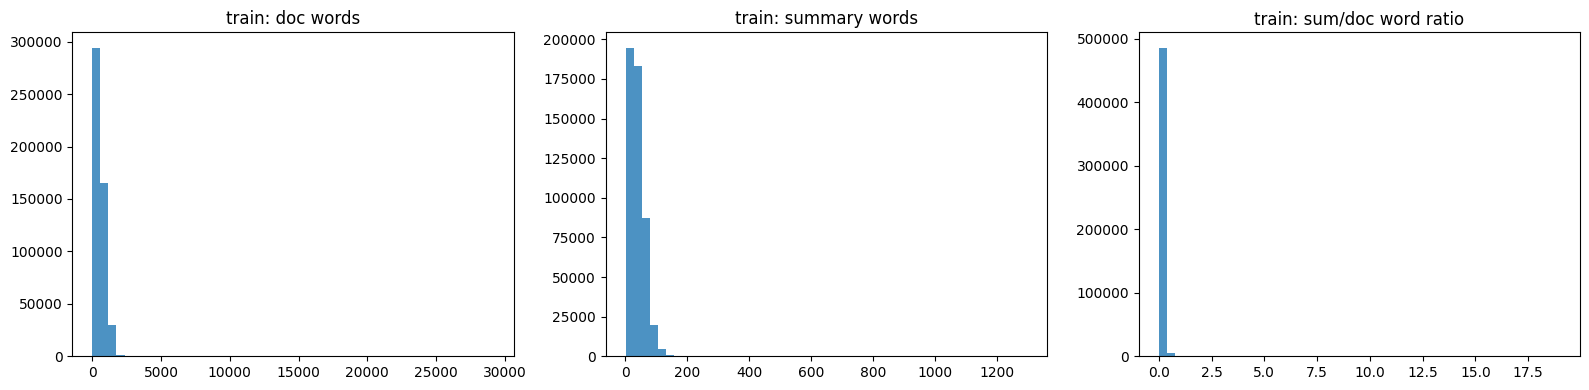

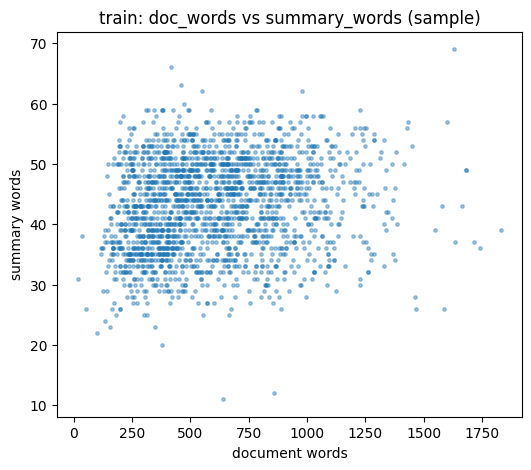

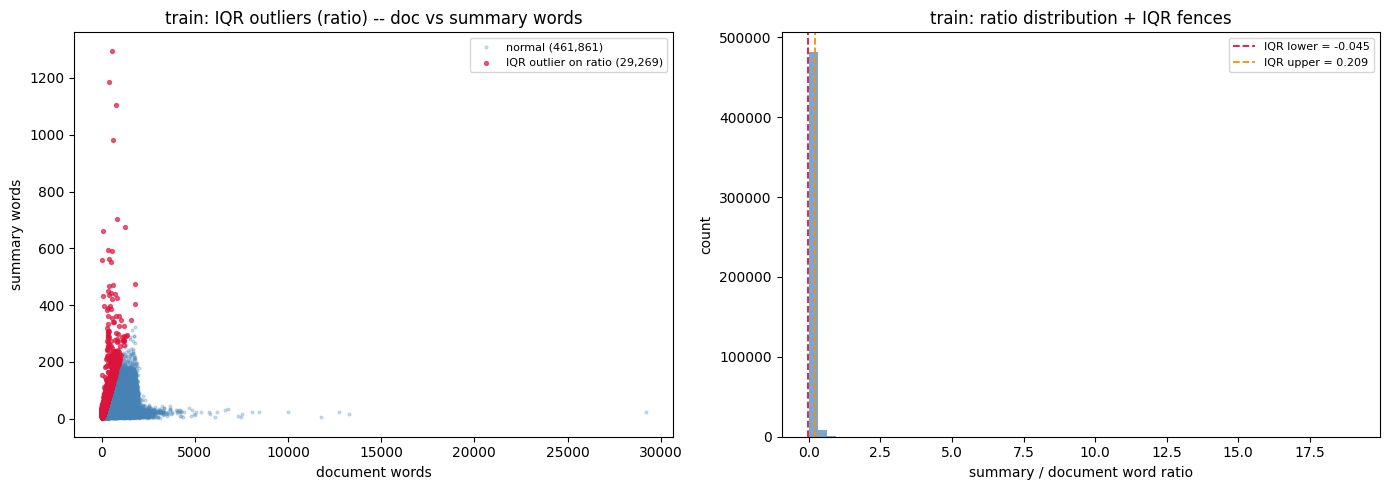


  Validation Report [train]   n = 491,130
  doc_words < 30   (too short to be 'long document')         588  ( 0.12%)
  doc_words > 1500 (training memory concern)               9,399  ( 1.91%)  <<
  sum_words < 10   (summary too short)                     2,242  ( 0.46%)
  sum_words > 150  (summary not concise)                     663  ( 0.13%)
  ratio > 1.0      (summary longer than document)            232  ( 0.05%)
  ratio < 0.02     (overly compressed)                    10,182  ( 2.07%)  <<
  ratio > 0.6      (barely compressed)                       948  ( 0.19%)
  IQR outlier on ratio                                      29,269  ( 5.96%)  <<
  IQR outlier on doc_words                                  11,295  ( 2.30%)



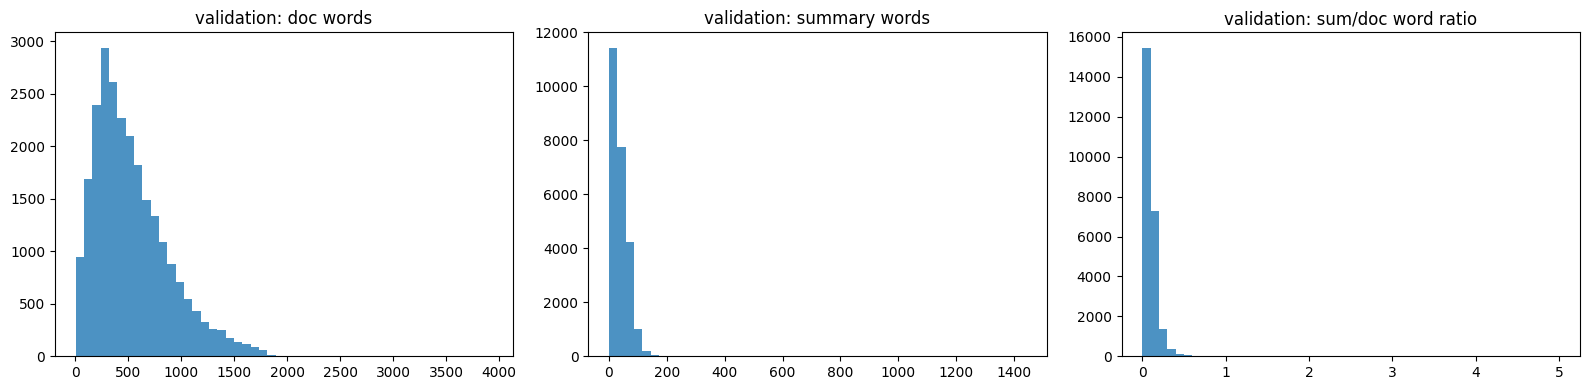

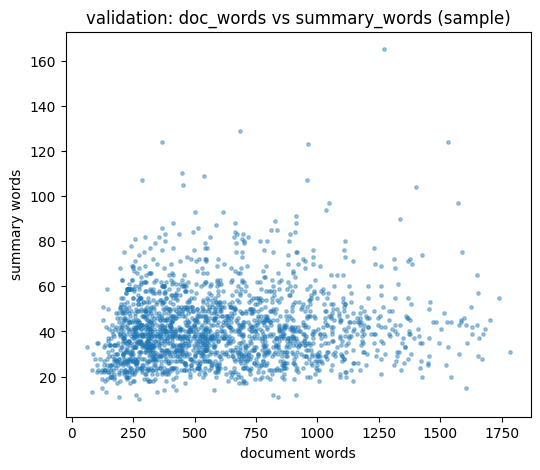

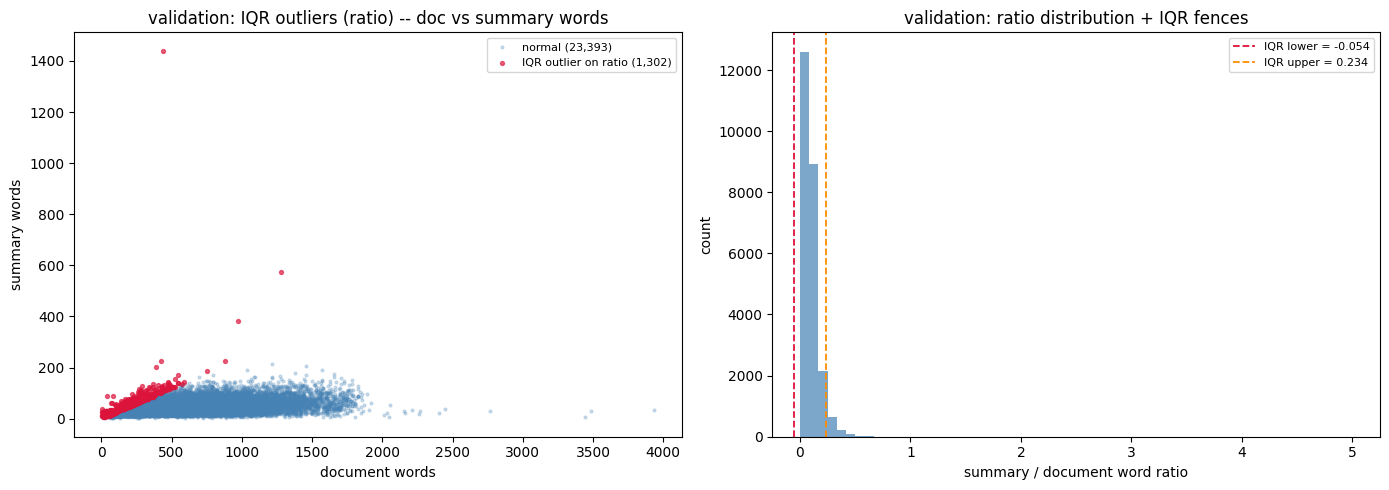


  Validation Report [validation]   n = 24,695
  doc_words < 30   (too short to be 'long document')          32  ( 0.13%)
  doc_words > 1500 (training memory concern)                 435  ( 1.76%)  <<
  sum_words < 10   (summary too short)                        95  ( 0.38%)
  sum_words > 150  (summary not concise)                      31  ( 0.13%)
  ratio > 1.0      (summary longer than document)             16  ( 0.06%)
  ratio < 0.02     (overly compressed)                       492  ( 1.99%)  <<
  ratio > 0.6      (barely compressed)                        46  ( 0.19%)
  IQR outlier on ratio                                       1,302  ( 5.27%)  <<
  IQR outlier on doc_words                                     646  ( 2.62%)



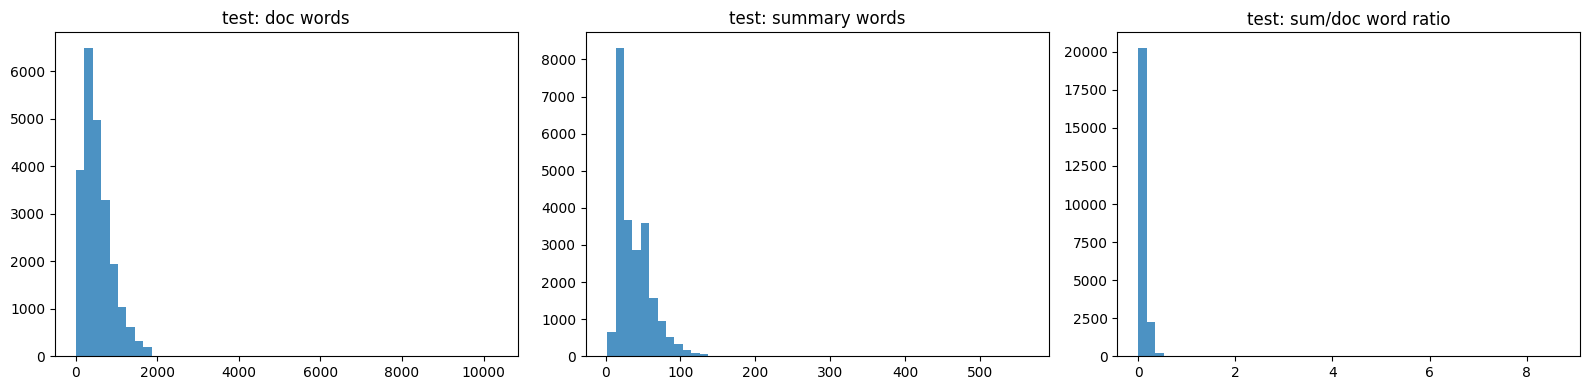

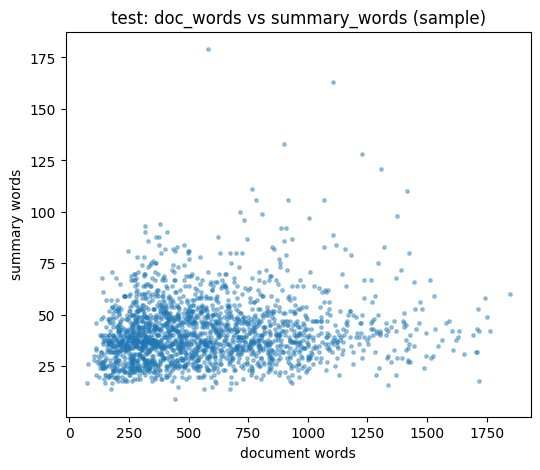

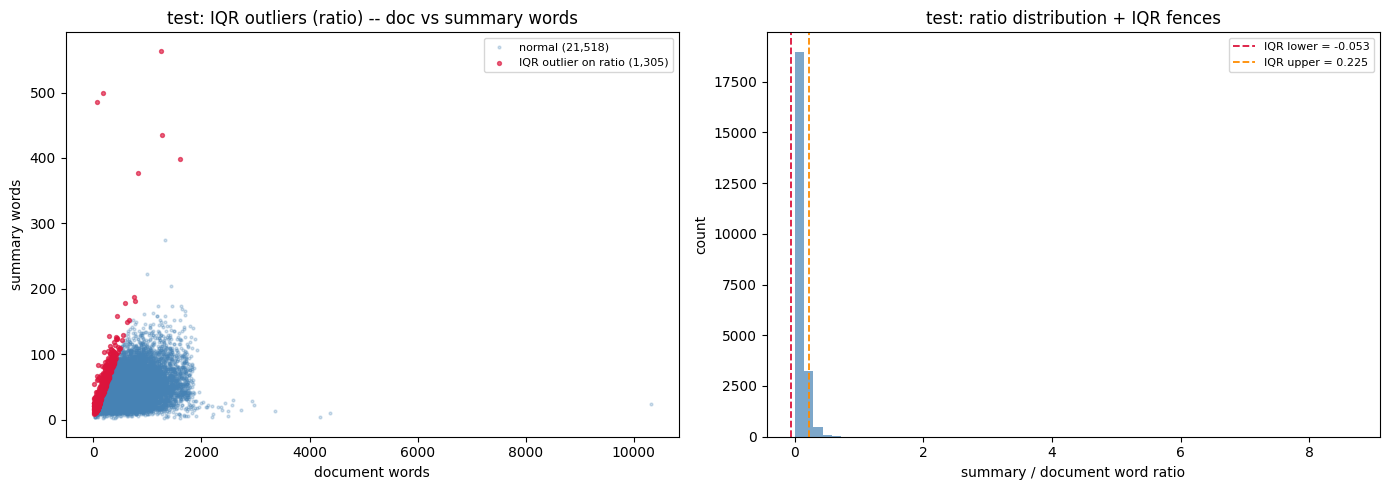


  Validation Report [test]   n = 22,823
  doc_words < 30   (too short to be 'long document')          32  ( 0.14%)
  doc_words > 1500 (training memory concern)                 427  ( 1.87%)  <<
  sum_words < 10   (summary too short)                       109  ( 0.48%)
  sum_words > 150  (summary not concise)                      30  ( 0.13%)
  ratio > 1.0      (summary longer than document)             18  ( 0.08%)
  ratio < 0.02     (overly compressed)                       482  ( 2.11%)  <<
  ratio > 0.6      (barely compressed)                        52  ( 0.23%)
  IQR outlier on ratio                                       1,305  ( 5.72%)  <<
  IQR outlier on doc_words                                     679  ( 2.98%)



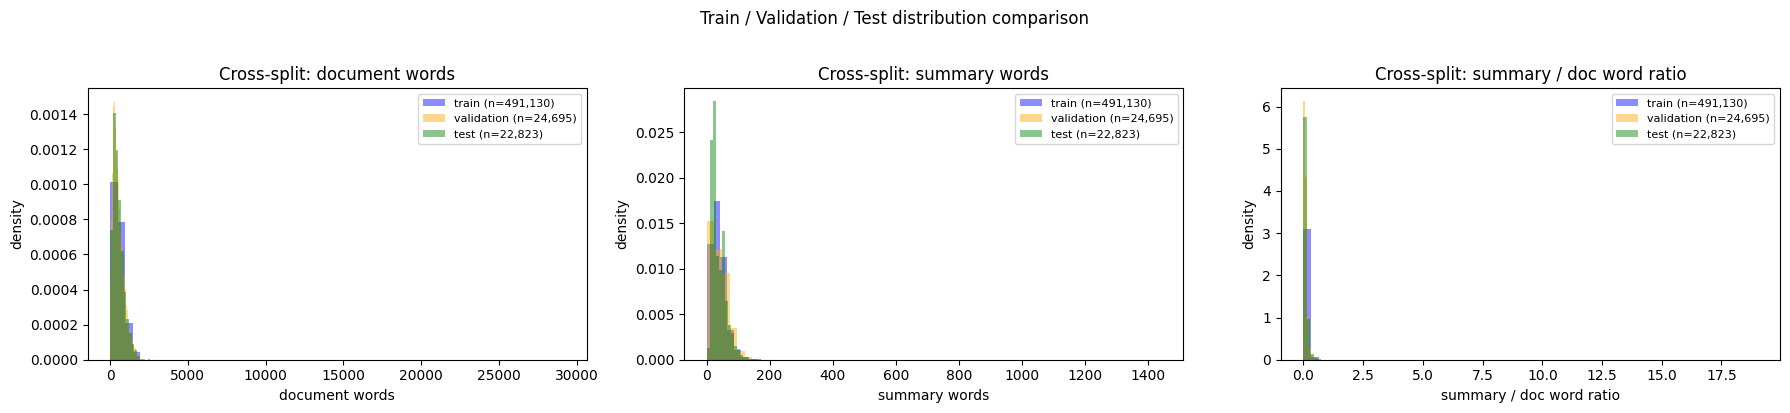

Within-split duplicates:
  [train       ]  491,130 rows  |  3,282 duplicates  <<
  [validation  ]   24,695 rows  |      0 duplicates
  [test        ]   22,823 rows  |      6 duplicates  <<

Cross-split document leakage:
  train ^ validation:  10 shared documents  [<< DATA LEAKAGE]
  train ^ test:  5 shared documents  [<< DATA LEAKAGE]
  validation ^ test:  1 shared documents  [<< DATA LEAKAGE]


In [ ]:
all_profiles: dict[str, dict] = {}

for split_name, ds in [("train",train), ("validation", validation), ("test", test)]:
    profile = profile_dataset(ds, sample_rows=None)
    all_profiles[split_name] = profile

    plot_profiles(profile, title_prefix=f"{split_name}:")
    plot_scatter(profile,  title_prefix=f"{split_name}:")
    plot_outliers(profile, title_prefix=f"{split_name}:")
    print_validation_report(profile, split_name=split_name)

plot_split_comparison(all_profiles)

detect_duplicates({"train": train, "validation": validation, "test": test})
